# Phase 2 — Structure-Aware GNN for Binding Affinity Prediction

This notebook trains the predictive model used as the core scoring engine in the project. The aim is to learn from the heterogeneous protein-ligand graphs built in Phase 1 and predict binding affinity while also testing whether auxiliary tasks improve the shared representation.

The modelling choices are intentionally practical rather than flashy. I want a graph architecture that is expressive enough to capture cross-type interactions, but still easy to explain and defend in a technical review.

In this phase, I will:
1. load the processed graph dataset,
2. define the `HeteroGNN` architecture,
3. train a multi-task model,
4. compare it against a single-task baseline, and
5. save the checkpoint that will later act as the frozen oracle for RL.

## 1. Imports and Configuration

This section pulls in the modelling stack, experiment settings, and training utilities. I keep the configuration close to the top so it is easy to reproduce the run or tweak hyperparameters later.

In [1]:
import sys, os, warnings, json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# MPS lacks scatter_reduce support needed by HGTConv — force CPU
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import HGTConv, Linear, global_mean_pool, global_add_pool
from torch_geometric.nn.aggr import AttentionalAggregation

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import MLFlowLogger

warnings.filterwarnings("ignore")
torch.manual_seed(42)

# ── Paths ────────────────────────────────────────────────────────────────
ROOT         = Path("..").resolve()
DATA_DIR     = ROOT / "data"
PROCESSED    = DATA_DIR / "processed"
CKPT_DIR     = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

# ── Dims (must match Phase 1 featurization) ──────────────────────────────
LIGAND_NODE_DIM  = 28
PROTEIN_NODE_DIM = 26

# ── Hyperparameters ──────────────────────────────────────────────────────
HID_DIM    = 128    # hidden channels in GNN
N_LAYERS   = 4      # HGTConv message-passing layers
N_HEADS    = 4      # attention heads per HGTConv layer
DROPOUT    = 0.1
LR         = 3e-4
BATCH_SIZE = 8
MAX_EPOCHS = 30     # capped for dry-run; increase to 100 for full training
PATIENCE   = 10

# MTL loss weights  (affinity · pose · selectivity)
LOSS_WEIGHTS = {"affinity": 1.0, "pose": 0.3, "selectivity": 0.3}

print(f"Torch: {torch.__version__}")
# HGTConv scatter_reduce not supported on MPS — use CPU
DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Torch: 2.3.1
Device: cpu


## 2. Load the Dataset from Phase 1

The graphs prepared in the first notebook are loaded here and wrapped for training. This keeps the modelling notebook focused on learning rather than repeating structural preprocessing.

In [2]:
cache_path = PROCESSED / "dataset.pt"
assert cache_path.exists(), (
    f"dataset.pt not found at {cache_path}\n"
    "Run phase1_data_graph_pipeline.ipynb first to build and cache graphs."
)

all_graphs = torch.load(cache_path, weights_only=False)
print(f"Loaded {len(all_graphs)} graphs from cache")

# ── Splits: 80 / 10 / 10 ────────────────────────────────────────────────
idx = list(range(len(all_graphs)))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_data = [all_graphs[i] for i in train_idx]
val_data   = [all_graphs[i] for i in val_idx]
test_data  = [all_graphs[i] for i in test_idx]

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_loader = PyGLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = PyGLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = PyGLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Quick sanity check
b = next(iter(train_loader))
print(f"\nBatch ligand  x : {b['ligand'].x.shape}")
print(f"Batch residue x : {b['residue'].x.shape}")
print(f"y_affinity      : {b.y_affinity.squeeze()}")
print(f"y_pose          : {b.y_pose.squeeze()}")

Loaded 150 graphs from cache
Train: 120 | Val: 15 | Test: 15

Batch ligand  x : torch.Size([239, 28])
Batch residue x : torch.Size([228, 26])
y_affinity      : tensor([6.5600, 6.5000, 4.7000, 7.0700, 7.1000, 6.8700, 6.7800, 6.4000])
y_pose          : tensor([1., 1., 0., 1., 1., 1., 1., 0.])


## 3. HeteroGNN Architecture

The model combines type-specific projections with heterogeneous message passing so that ligand atoms and pocket residues can interact without collapsing into a single undifferentiated node space.

```text
Input: ligand nodes [L,28] + residue nodes [P,26]
  ↓
Linear projections → hidden dim 128
  ↓
4 × HGTConv layers (heterogeneous graph transformer)
  each layer: self-attention across all 4 edge types + residual
  ↓
AttentionalAggregation readout (separate for ligand & residue)
  ↓
Concat [ligand_pool || residue_pool] → 256-dim
  ↓
Shared MLP trunk (256→128→64)
  ↓
Affinity head + pose head + selectivity head
```

I chose this design because it preserves the distinction between chemistry and pocket context while still allowing rich cross-type information flow.

In [3]:
class HeteroGNN(nn.Module):
    """
    4-layer Heterogeneous Graph Transformer for protein-ligand binding affinity.
    Handles 2 node types (ligand, residue) and 4 edge types.
    """

    NODE_TYPES = ["ligand", "residue"]
    EDGE_TYPES = [
        ("ligand",  "bond",       "ligand"),
        ("residue", "contact",    "residue"),
        ("residue", "interacts",  "ligand"),
        ("ligand",  "interacts",  "residue"),
    ]
    META = (NODE_TYPES, EDGE_TYPES)

    def __init__(
        self,
        lig_in:   int = LIGAND_NODE_DIM,
        prot_in:  int = PROTEIN_NODE_DIM,
        hidden:   int = HID_DIM,
        n_layers: int = N_LAYERS,
        n_heads:  int = N_HEADS,
        dropout:  float = DROPOUT,
        multitask: bool = True,
    ):
        super().__init__()
        self.multitask = multitask
        self.n_layers  = n_layers

        # ── Input projections ──────────────────────────────────────────
        self.lig_proj  = nn.Sequential(
            nn.Linear(lig_in,  hidden), nn.LayerNorm(hidden), nn.ReLU()
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(prot_in, hidden), nn.LayerNorm(hidden), nn.ReLU()
        )

        # ── HGTConv layers + layer norms + residual ────────────────────
        self.convs = nn.ModuleList([
            HGTConv(
                in_channels  = {nt: hidden for nt in self.NODE_TYPES},
                out_channels = hidden,
                metadata     = self.META,
                heads        = n_heads,
            )
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([
            nn.ModuleDict({
                nt: nn.LayerNorm(hidden) for nt in self.NODE_TYPES
            })
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        # ── Attention pooling readout (separate gate per node type) ────
        self.lig_pool  = AttentionalAggregation(gate_nn=nn.Linear(hidden, 1))
        self.prot_pool = AttentionalAggregation(gate_nn=nn.Linear(hidden, 1))

        # ── Shared MLP trunk ───────────────────────────────────────────
        self.trunk = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
        )

        # ── Output heads ───────────────────────────────────────────────
        head_in = hidden // 2
        self.affinity_head    = nn.Linear(head_in, 1)
        self.pose_head        = nn.Linear(head_in, 1)      # active only if multitask
        self.selectivity_head = nn.Linear(head_in, 1)      # active only if multitask

    def forward(self, batch: HeteroData) -> Dict[str, torch.Tensor]:
        # ── Project inputs to hidden dim ──────────────────────────────
        x_dict = {
            "ligand":  self.lig_proj(batch["ligand"].x),
            "residue": self.prot_proj(batch["residue"].x),
        }

        # Build edge_index_dict — skip missing edge types gracefully
        edge_index_dict = {}
        for et in self.EDGE_TYPES:
            try:
                edge_index_dict[et] = batch[et].edge_index
            except (AttributeError, KeyError):
                pass  # HGTConv tolerates missing edge types

        # ── 4 message-passing layers with residual + LayerNorm ────────
        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, edge_index_dict)
            for nt in self.NODE_TYPES:
                if nt in x_new and x_new[nt] is not None:
                    x_dict[nt] = norm_dict[nt](
                        self.dropout(x_new[nt]) + x_dict[nt]   # residual
                    )

        # ── Attention pooling → graph-level embeddings ────────────────
        lig_emb  = self.lig_pool(x_dict["ligand"],
                                  batch["ligand"].batch)
        prot_emb = self.prot_pool(x_dict["residue"],
                                   batch["residue"].batch)

        # ── Shared trunk ──────────────────────────────────────────────
        graph_emb = self.trunk(torch.cat([lig_emb, prot_emb], dim=-1))

        # ── Heads ─────────────────────────────────────────────────────
        out = {"affinity": self.affinity_head(graph_emb).squeeze(-1)}
        if self.multitask:
            out["pose"]        = self.pose_head(graph_emb).squeeze(-1)
            out["selectivity"] = self.selectivity_head(graph_emb).squeeze(-1)
        return out


# ── Quick shape check ─────────────────────────────────────────────────────
model_test = HeteroGNN().to(DEVICE)
b_test = next(iter(train_loader))
# move batch to device
b_test = b_test.to(DEVICE)
with torch.no_grad():
    out_test = model_test(b_test)

print("Forward pass OK")
for k, v in out_test.items():
    print(f"  {k}: {v.shape}  sample={v[:3].cpu().numpy().round(3)}")

total_params = sum(p.numel() for p in model_test.parameters())
print(f"\nTotal parameters: {total_params:,}")

Forward pass OK
  affinity: torch.Size([8])  sample=[0.224 0.121 0.174]
  pose: torch.Size([8])  sample=[0.278 0.173 0.219]
  selectivity: torch.Size([8])  sample=[-0.057  0.041  0.074]

Total parameters: 711,117


## 4. Multi-Task Loss

Binding affinity is the main objective, but I also include pose quality and selectivity as auxiliary tasks. The idea is that related supervision can regularize the shared encoder and encourage it to learn a more useful structural representation.

In [4]:
class MTLLoss(nn.Module):
    """
    Multi-task loss with learned uncertainty weighting (Kendall et al. 2018).
    
    Instead of fixed weights, learn log(sigma^2) per task.
    Loss_i = (1/2σ_i²) * task_loss_i + log(σ_i)
    
    This auto-balances tasks during training without manual tuning.
    Falls back to fixed weights when multitask=False.
    """

    def __init__(self, multitask: bool = True,
                 weights: Dict[str, float] = LOSS_WEIGHTS):
        super().__init__()
        self.multitask = multitask
        self.weights   = weights

        if multitask:
            # Learnable log variances — one per task
            self.log_var_aff  = nn.Parameter(torch.zeros(1))
            self.log_var_pose = nn.Parameter(torch.zeros(1))
            self.log_var_sel  = nn.Parameter(torch.zeros(1))

    def forward(self, preds: Dict[str, torch.Tensor],
                batch: HeteroData) -> Tuple[torch.Tensor, Dict[str, float]]:

        y_aff  = batch.y_affinity.squeeze().to(preds["affinity"].device)
        loss_aff = F.mse_loss(preds["affinity"], y_aff)

        components = {"loss_affinity": loss_aff.item()}

        if not self.multitask:
            return loss_aff, components

        # Pose quality head
        y_pose = batch.y_pose.squeeze().to(preds["pose"].device)
        loss_pose = F.binary_cross_entropy_with_logits(preds["pose"], y_pose)
        components["loss_pose"] = loss_pose.item()

        # Selectivity head
        y_sel = batch.y_select.squeeze().to(preds["selectivity"].device)
        loss_sel = F.binary_cross_entropy_with_logits(preds["selectivity"], y_sel)
        components["loss_selectivity"] = loss_sel.item()

        # Uncertainty-weighted combination
        loss = (
            torch.exp(-self.log_var_aff)  * loss_aff  + 0.5 * self.log_var_aff
          + torch.exp(-self.log_var_pose) * loss_pose + 0.5 * self.log_var_pose
          + torch.exp(-self.log_var_sel)  * loss_sel  + 0.5 * self.log_var_sel
        )
        components["loss_total"] = loss.item()
        components["sigma_aff"]  = float(torch.exp(0.5 * self.log_var_aff).item())
        components["sigma_pose"] = float(torch.exp(0.5 * self.log_var_pose).item())
        components["sigma_sel"]  = float(torch.exp(0.5 * self.log_var_sel).item())
        return loss, components


# Sanity check
criterion_test = MTLLoss(multitask=True)
loss_val, comps = criterion_test(out_test, b_test.cpu())
print(f"MTL loss: {loss_val.item():.4f}")
for k, v in comps.items():
    print(f"  {k}: {v:.4f}")

MTL loss: 54.4672
  loss_affinity: 53.1350
  loss_pose: 0.6386
  loss_selectivity: 0.6936
  loss_total: 54.4672
  sigma_aff: 1.0000
  sigma_pose: 1.0000
  sigma_sel: 1.0000


## 5. PyTorch Lightning Module

This section wraps the model, loss computation, metrics, and optimizer setup in a Lightning module. That keeps the training loop readable and makes checkpointing and logging much less error-prone.

In [5]:
class GNNBindModule(pl.LightningModule):
    """
    PyTorch Lightning wrapper for HeteroGNN.
    Tracks: train/val RMSE, Pearson R, pose AUC, selectivity AUC.
    """

    def __init__(self, multitask: bool = True, lr: float = LR):
        super().__init__()
        self.save_hyperparameters()
        self.model     = HeteroGNN(multitask=multitask)
        self.criterion = MTLLoss(multitask=multitask)
        self.multitask = multitask
        self.lr        = lr

        self._val_preds       = []
        self._val_labels      = []
        self._val_pose_logits = []
        self._val_pose_labels = []

    def training_step(self, batch, batch_idx):
        preds = self.model(batch)
        loss, comps = self.criterion(preds, batch)
        self.log("train/loss", loss, prog_bar=True, batch_size=BATCH_SIZE)
        for k, v in comps.items():
            self.log(f"train/{k}", v, batch_size=BATCH_SIZE)
        return loss

    def validation_step(self, batch, batch_idx):
        preds = self.model(batch)
        loss, _ = self.criterion(preds, batch)
        self.log("val/loss", loss, prog_bar=True, batch_size=BATCH_SIZE)
        self._val_preds.append(preds["affinity"].detach().cpu())
        self._val_labels.append(batch.y_affinity.squeeze().cpu())
        if self.multitask:
            self._val_pose_logits.append(preds["pose"].detach().cpu())
            self._val_pose_labels.append(batch.y_pose.squeeze().cpu())

    def on_validation_epoch_end(self):
        if not self._val_preds:
            return
        preds  = torch.cat(self._val_preds).numpy()
        labels = torch.cat(self._val_labels).numpy()
        rmse = float(np.sqrt(np.mean((preds - labels) ** 2)))
        r, _ = pearsonr(preds, labels) if len(preds) > 2 else (0.0, 1.0)
        # log both namespaced (for display) and flat (for checkpoint filename)
        self.log("val/rmse",    rmse, prog_bar=True)
        self.log("val/pearson", r,    prog_bar=True)
        self.log("val_rmse",    rmse)   # flat name — used in ModelCheckpoint filename

        if self.multitask and self._val_pose_logits:
            pose_logits = torch.cat(self._val_pose_logits).sigmoid().numpy()
            pose_labels = torch.cat(self._val_pose_labels).numpy()
            if len(np.unique(pose_labels)) > 1:
                self.log("val/pose_auc", roc_auc_score(pose_labels, pose_logits))

        self._val_preds.clear(); self._val_labels.clear()
        self._val_pose_logits.clear(); self._val_pose_labels.clear()

    def configure_optimizers(self):
        opt = Adam(self.parameters(), lr=self.lr, weight_decay=1e-5)
        sched = ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5, min_lr=1e-6)
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "monitor": "val/loss", "interval": "epoch"},
        }


print("GNNBindModule defined.")

GNNBindModule defined.


## 6. Train the Multi-Task Model

Here I fit the full multi-task version of the model and track the main metrics. The goal is not just to minimize loss, but to see whether the shared encoder converges to a stable and usable representation.

In [6]:
callbacks_mtl = [
    EarlyStopping(monitor="val/loss", patience=PATIENCE, mode="min", verbose=False),
    ModelCheckpoint(
        dirpath=str(CKPT_DIR),
        filename="gnn_mtl-{epoch:02d}-{val_rmse:.3f}",
        monitor="val/rmse",
        mode="min",
        save_top_k=1,
        verbose=True,
    ),
]

module_mtl = GNNBindModule(multitask=True, lr=LR)

trainer_mtl = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=callbacks_mtl,
    enable_progress_bar=True,
    enable_model_summary=True,
    log_every_n_steps=1,
    accelerator="cpu",
)

print("Training MTL model …")
trainer_mtl.fit(module_mtl, train_loader, val_loader)
print(f"Best MTL checkpoint: {callbacks_mtl[1].best_model_path}")
print(f"Best val RMSE      : {callbacks_mtl[1].best_model_score:.4f}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training MTL model …


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ HeteroGNN │  711 K │ train │     0 │
│ 1 │ criterion │ MTLLoss   │      3 │ train │     0 │
└───┴───────────┴───────────┴────────┴───────┴───────┘

Trainable params: 711 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 711 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 95                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Epoch 0, global step 15: 'val/rmse' reached 5.31185 (best 5.31185), saving model to '/Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=00-val_rmse=5.312.ckpt' as top 1
Epoch 1, global step 30: 'val/rmse' reached 4.51618 (best 4.51618), saving model to '/Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=01-val_rmse=4.516.ckpt' as top 1
Epoch 2, global step 45: 'val/rmse' reached 3.58148 (best 3.58148), saving model to '/Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=02-val_rmse=3.581.ckpt' as top 1
Epoch 3, global step 60: 'val/rmse' reached 2.80109 (best 2.80109), saving model to '/Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=03-val_rmse=2.801.ckpt' as top 1
Epoch 4, global step 75: 'val/rmse' reached 2.29779 (best 2.29779), saving model to '/Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=04-val_rmse=2.298.ckpt' as top 1
Epoch 5, global step 90: 'val/rmse' reached 2.08294 (best 2.08294), saving model to '/User

Best MTL checkpoint: /Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=19-val_rmse=1.924.ckpt
Best val RMSE      : 1.9244


## 7. Ablation: Single-Task Baseline

To tell a credible story, the multi-task model needs a fair comparison point. This section trains a binding-affinity-only baseline so we can test whether the auxiliary tasks are genuinely helping or just adding complexity.

In [7]:
callbacks_stl = [
    EarlyStopping(monitor="val/loss", patience=PATIENCE, mode="min", verbose=False),
    ModelCheckpoint(
        dirpath=str(CKPT_DIR),
        filename="gnn_stl-{epoch:02d}-{val_rmse:.3f}",
        monitor="val/rmse",
        mode="min",
        save_top_k=1,
        verbose=False,
    ),
]

module_stl = GNNBindModule(multitask=False, lr=LR)

trainer_stl = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=callbacks_stl,
    enable_progress_bar=True,
    enable_model_summary=False,
    log_every_n_steps=1,
    accelerator="cpu",
)

print("Training STL (single-task, affinity-only) model …")
trainer_stl.fit(module_stl, train_loader, val_loader)
print(f"Best STL checkpoint: {callbacks_stl[1].best_model_path}")
print(f"Best val RMSE      : {callbacks_stl[1].best_model_score:.4f}")

# ── Ablation summary ──────────────────────────────────────────────────────
mtl_rmse = float(callbacks_mtl[1].best_model_score)
stl_rmse = float(callbacks_stl[1].best_model_score)
delta    = stl_rmse - mtl_rmse
print(f"\n{'='*45}")
print(f"  MTL (pose + selectivity aux tasks) : {mtl_rmse:.4f}")
print(f"  STL (affinity only)                : {stl_rmse:.4f}")
print(f"  Δ RMSE (positive = MTL wins)       : {delta:+.4f}")
print(f"{'='*45}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Training STL (single-task, affinity-only) model …


Best STL checkpoint: /Users/sourav/personal-github/Excer-1/checkpoints/gnn_stl-epoch=09-val_rmse=2.034.ckpt
Best val RMSE      : 2.0337

  MTL (pose + selectivity aux tasks) : 1.9244
  STL (affinity only)                : 2.0337
  Δ RMSE (positive = MTL wins)       : +0.1093


## 8. Test Set Evaluation

Once training is complete, I evaluate the final models on the held-out test set. This is where the comparison between the single-task and multi-task setups becomes meaningful.

In [8]:
def evaluate_on_test(module: GNNBindModule, loader, device=DEVICE):
    """Run test set inference; return dict of metrics + raw arrays."""
    module.eval().to(device)
    all_preds, all_labels = [], []
    all_pose_logits, all_pose_labels = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            preds = module.model(batch)
            all_preds.append(preds["affinity"].cpu())
            all_labels.append(batch.y_affinity.squeeze().cpu())
            if module.multitask:
                all_pose_logits.append(preds["pose"].cpu())
                all_pose_labels.append(batch.y_pose.squeeze().cpu())

    p = torch.cat(all_preds).numpy()
    y = torch.cat(all_labels).numpy()
    rmse = float(np.sqrt(np.mean((p - y) ** 2)))
    mae  = float(np.mean(np.abs(p - y)))
    r, _ = pearsonr(p, y)

    metrics = {"rmse": rmse, "mae": mae, "pearson_r": r}

    if module.multitask and all_pose_logits:
        pl_logits = torch.cat(all_pose_logits).sigmoid().numpy()
        pl_labels = torch.cat(all_pose_labels).numpy()
        if len(np.unique(pl_labels)) > 1:
            metrics["pose_auc"] = roc_auc_score(pl_labels, pl_logits)

    return metrics, p, y


# Load best MTL checkpoint
best_mtl_path = callbacks_mtl[1].best_model_path
module_best   = GNNBindModule.load_from_checkpoint(best_mtl_path)
test_metrics, test_preds, test_labels = evaluate_on_test(module_best, test_loader)

print("── Test Set Results (MTL model) ──────────────────")
for k, v in test_metrics.items():
    print(f"  {k:15s}: {v:.4f}")
print("──────────────────────────────────────────────────")

── Test Set Results (MTL model) ──────────────────
  rmse           : 1.7022
  mae            : 1.4918
  pearson_r      : 0.5786
  pose_auc       : 0.7963
──────────────────────────────────────────────────


## 9. Visualizations

The plots in this section are meant to make the model behavior easier to interpret. I use them to look at overall fit quality, compare ablations, and identify whether performance gains are real or mostly cosmetic.

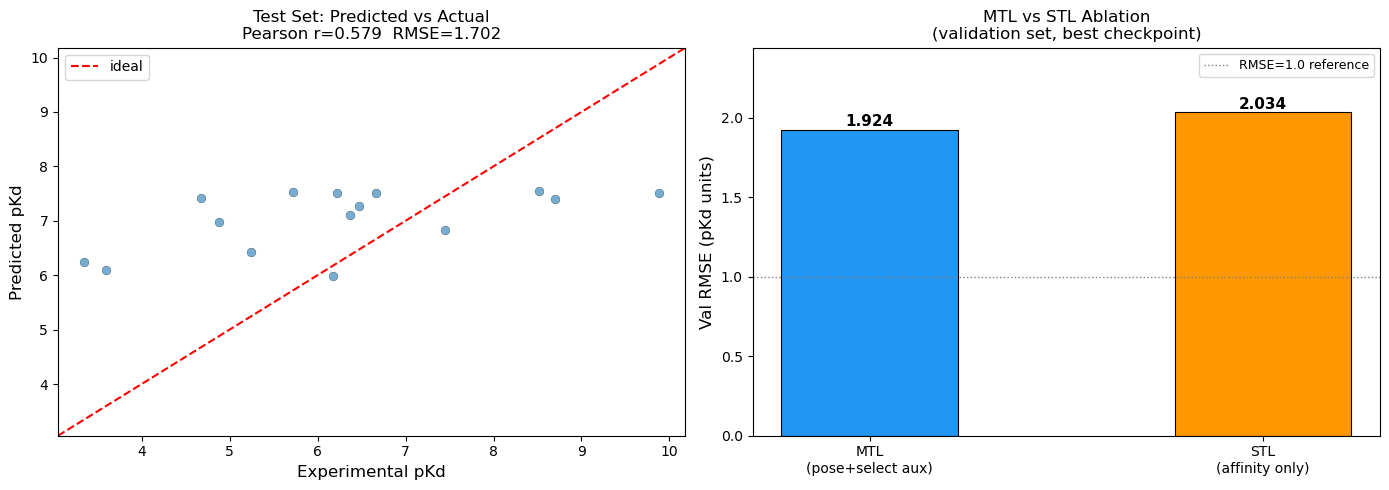

Figure saved → checkpoints/phase2_results.png


In [9]:
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.6))
fig.patch.set_facecolor("white")

# ── Panel A: Predicted vs Actual (test set) ───────────────────────────────
ax = axes[0]
r = test_metrics["pearson_r"]
rmse = test_metrics["rmse"]
n_test = len(test_labels)
lo = min(test_labels.min(), test_preds.min()) - 0.3
hi = max(test_labels.max(), test_preds.max()) + 0.3
ax.scatter(
    test_labels,
    test_preds,
    alpha=0.68,
    s=26,
    color="#4C78A8",
    edgecolors="white",
    linewidths=0.35,
)
ax.plot([lo, hi], [lo, hi], linestyle="--", color="#888888", lw=1.0)
ax.set_xlabel("Experimental pKd")
ax.set_ylabel("Predicted pKd")
ax.set_title("Test parity", pad=10)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
stats_text = (
    f"n = {n_test}\n"
    f"r = {r:.3f}\n"
    f"RMSE = {rmse:.3f}"
)
ax.text(
    0.98, 0.96, stats_text,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", linewidth=0.6),
)
ax.text(
    -0.12, 1.10, "a)",
    transform=ax.transAxes, ha="left", va="bottom",
    fontsize=10, fontweight="bold", color="#222222",
)

# ── Panel B: MTL vs STL ablation bar chart ────────────────────────────────
ax = axes[1]
labels_ab = ["MTL\n(aux tasks)", "STL\n(affinity only)"]
vals_ab = [mtl_rmse, stl_rmse]
colors = ["#72B7B2", "#B279A2"]
bars = ax.bar(labels_ab, vals_ab, color=colors, width=0.52, edgecolor="#FFFFFF", linewidth=0.6)
for bar, v in zip(bars, vals_ab):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.015,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#222222",
    )
ax.set_ylabel("Validation RMSE (pKd)")
ax.set_title("MTL ablation", pad=10)
ax.set_ylim(0, max(vals_ab) * 1.22)
ax.axhline(y=1.0, color="#999999", linestyle=":", lw=0.9)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
delta_text = (
    f"MTL gain = {stl_rmse - mtl_rmse:.3f}\n"
    f"best ckpt\n"
    f"ref = RMSE 1.0"
)
ax.text(
    0.98, 0.96, delta_text,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", linewidth=0.6),
)
ax.text(
    -0.12, 1.10, "b)",
    transform=ax.transAxes, ha="left", va="bottom",
    fontsize=10, fontweight="bold", color="#222222",
)

fig.subplots_adjust(left=0.11, right=0.98, bottom=0.18, top=0.86, wspace=0.34)
plt.savefig(str(ROOT / "checkpoints" / "phase2_results.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved → checkpoints/phase2_results.png")

## 10. Export the Model for Phase 3

The trained checkpoint is saved here so it can be reused as a frozen scoring oracle in the reinforcement learning notebook. Keeping that handoff explicit makes the transition between phases much cleaner.

In [10]:
import shutil

SRC_MODELS = ROOT / "src" / "models"
SRC_MODELS.mkdir(parents=True, exist_ok=True)

# Copy best checkpoint to src/models/ so Phase 3 can import it
dst = SRC_MODELS / "gnn_best.ckpt"
shutil.copy2(best_mtl_path, dst)
print(f"Checkpoint copied → {dst}")

# Also save a lightweight state dict for inference
state = {
    "model_state_dict": module_best.model.state_dict(),
    "hparams": {
        "multitask":  True,
        "lig_in":     LIGAND_NODE_DIM,
        "prot_in":    PROTEIN_NODE_DIM,
        "hidden":     HID_DIM,
        "n_layers":   N_LAYERS,
        "n_heads":    N_HEADS,
        "dropout":    DROPOUT,
    },
    "test_metrics": test_metrics,
}
torch.save(state, SRC_MODELS / "gnn_state.pt")
print(f"State dict  saved → {SRC_MODELS / 'gnn_state.pt'}")

print("\n── Phase 2 complete ──────────────────────────────")
print(f"  Best checkpoint : {best_mtl_path}")
print(f"  Test RMSE       : {test_metrics['rmse']:.4f}")
print(f"  Test Pearson r  : {test_metrics['pearson_r']:.4f}")
if "pose_auc" in test_metrics:
    print(f"  Pose AUC        : {test_metrics['pose_auc']:.4f}")
print("  → Ready for Phase 3: RL molecular generator")

Checkpoint copied → /Users/sourav/personal-github/Excer-1/src/models/gnn_best.ckpt
State dict  saved → /Users/sourav/personal-github/Excer-1/src/models/gnn_state.pt

── Phase 2 complete ──────────────────────────────
  Best checkpoint : /Users/sourav/personal-github/Excer-1/checkpoints/gnn_mtl-epoch=19-val_rmse=1.924.ckpt
  Test RMSE       : 1.7022
  Test Pearson r  : 0.5786
  Pose AUC        : 0.7963
  → Ready for Phase 3: RL molecular generator
